###### Content under Creative Commons Attribution license CC-BY 3.0, code under BSD 3-Clause License © 2026 by D. Koehn and T. Meier, notebook style sheet by L.A. Barba, N.C. Clementi

# Probability and Statistics of a 6-Sided Dice

Daniel Köhn

Kiel, the 27th of April 2026

In the lecture, I introduced some basic concepts of probability using a 6-sided dice as an example. In this notebook, we will compare the theoretical probability model with a real-world dice experiment.

## Probability Model for the fair 6-sided Dice

The mathematical foundation for describing any stochastic model is a
**probability space**, which consists of three components ...

- ... the **result space** $\Omega$, which contains all possible outcomes of a random experiment. In the case of a 6-sided dice, this means the numbers on a possible roll: $\Omega = \{1,2,3,4,5,6\}$.
- ... the **event space** $A \subseteq \Omega$, which contains the outcomes of the random experiment that we are interested in. In the case of the dice, we might be interested in all events where a 1 or 6 was rolled, i.e., $A = \{1,6\}$
- ... the **probability measure**, which specifies the probability that an event occurs. For an (unloaded) dice, the probabilities of rolling a number should be uniformly distributed and can be calculated using the [Laplace formula](https://de.wikipedia.org/wiki/Laplace-Formel). It follows that for the probability measure $W(A) = \{\frac{1}{6},\frac{1}{6}\}$

Finally, we must define a **random variable** $X$, which in this case is the number rolled on the dice. 

In the next step, we plot the **probability density function $p$** by plotting the probability measure against the values of the random variable for the sample space ...

In [1]:
# Import Python Libraries
# -----------------------
import numpy as np        
import matplotlib.pyplot as plt

Define values of the random variable $X$ and the probability density function $p$ 

In [2]:
# Define X and p
X = np.arange(1,7)
p = np.ones(6) * 1/6

print('X = ', X)
print('p = ', p)

X =  [1 2 3 4 5 6]
p =  [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]


Plot probability density function as a bar chart

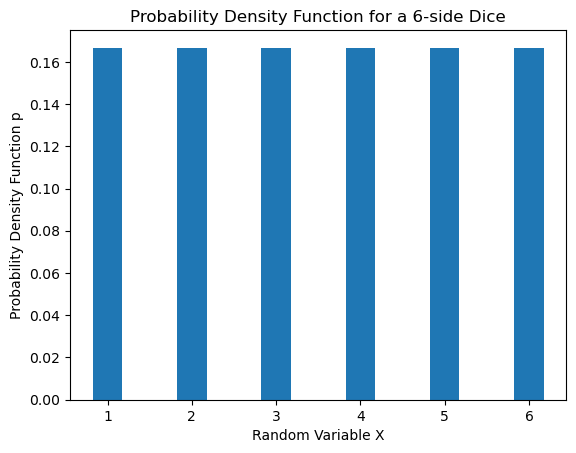

In [3]:
width = 0.35       # Breite der Bars
pp = plt.bar(X, p, width, label='p')
plt.ylabel('Probability Density Function p')
plt.xlabel('Random Variable X')
plt.title('Probability Density Function for a 6-side Dice')
plt.show()

As we can see, the probabilities of rolling a number are uniformly distributed. Next, we can calculate the **probability distribution $P$** from the probability density function. For the continuous case, this is done by integrating the probability density function:

$P(s) = \int_{-\infty}^s p(s') ds'$

In the discrete case, as with the dice here, the integral is replaced by a sum:

$P_n = \sum_{i=1}^n p_i$ 

where $n \in \{1,2,3,4,5,6\}$. In Python, we can easily compute the sum using the NumPy function `cumsum` from the vector p:

In [4]:
# Estimate Probability Distribution P from Probability Density Distribution p
P = np.cumsum(p)
print('P = ', P)

P =  [0.16666667 0.33333333 0.5        0.66666667 0.83333333 1.        ]


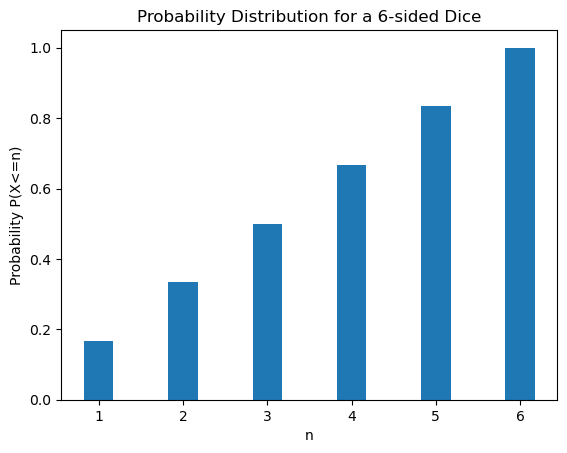

In [5]:
width = 0.35       # define width of bars
Pp = plt.bar(X, P, width, label='P')
plt.ylabel('Probability P(X<=n)')
plt.xlabel('n')
plt.title('Probability Distribution for a 6-sided Dice')
plt.show()

Finally, we can calculate the **expected value E[X]** of the random variable from the probability density function $p$. In the continuous case, we have:

$m_1 = E[X] = \int_{-\infty}^{\infty} s' p(s') ds'$

In the discrete case, we replace the integral with a sum. For the dice, we have:

$ E[X] = \sum_{i=1}^6 X_i p_i$

which we can easily implement in Python ...

In [6]:
E = np.sum(X*p)
print('E = ',E)

E =  3.5


At this point, it is worth noting once again that the expected value **is not** the same as the arithmetic mean. The expected value is based on a probabilistic model of the dice. In contrast, the arithmetic mean is based on a statistical analysis of a sample from a real-world random experiment, such as rolling a fair dice 1,000 times.

## Comparison with a “real” Dice

Let's compare the dice's probability model with a real-world random experiment in which I rolled a real, physical dice 1,026 times. You can find the results in the ASCII file `wuerfel.txt`. Let's import the data...

In [7]:
dice = np.loadtxt('data/wuerfel/wuerfel.txt', delimiter='\t', skiprows=0, unpack='False')

... and visualize them with the Plot function ...

Text(0.5, 1.0, 'Analog Dice Experiment')

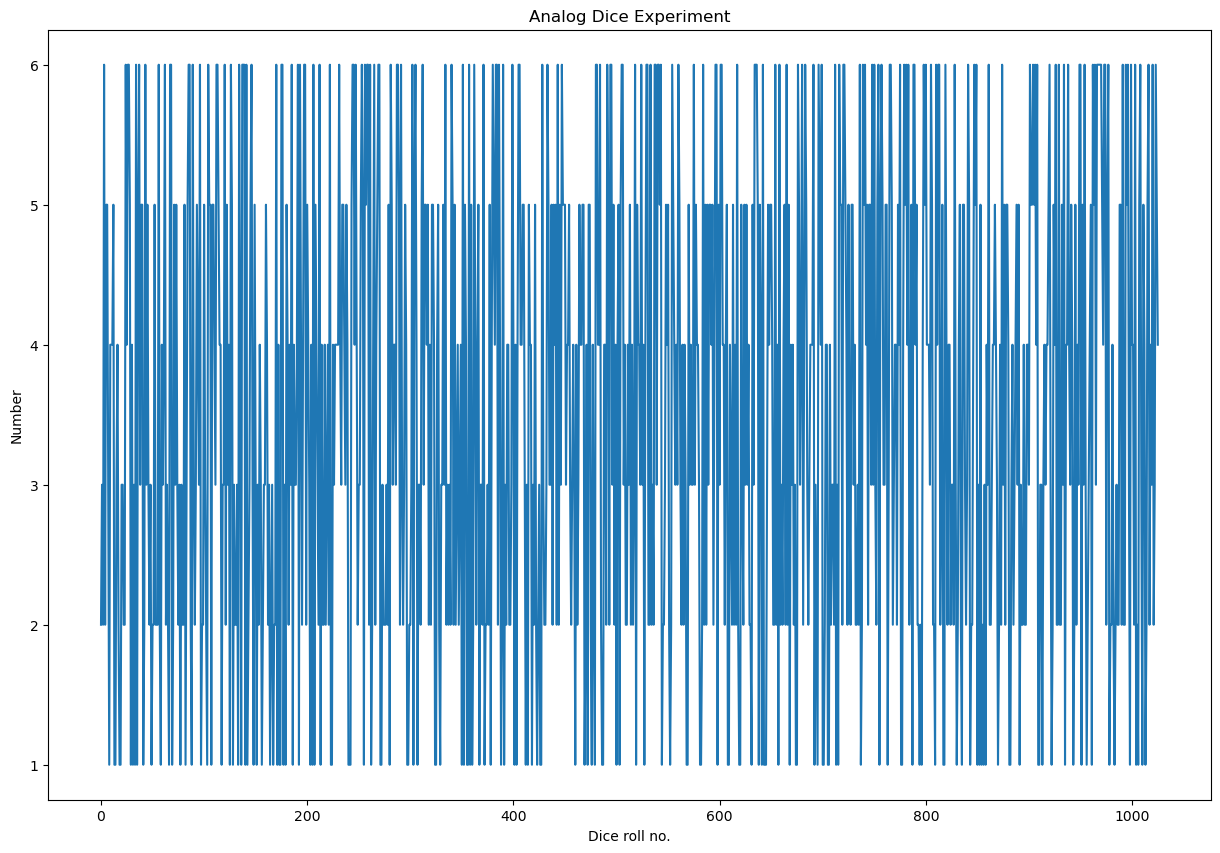

In [8]:
fig = plt.figure(figsize=(15., 10.))
plt.plot(dice)
plt.xlabel('Dice roll no.')
plt.ylabel('Number')
plt.title('Analog Dice Experiment')

At first glance, it looks pretty evenly distributed. Let's calculate the probability density function for the analog dice experiment.

In [9]:
# Compute Probability density distribution

n = np.size(dice) # Estimate number of dice rolls in the dataset
#n = 6            # option ot limit number of dice rolls

pdice = np.zeros(6)   # Initialize Probability Density Distribution with Zeros

for i in range(0,6):         # For-Loop over Random Variable (Number on the Dice)    
    count = 0                # Counter for the occurence of random variable i
    for j in range(1, n):    # For-Loop over all dice rolls within the dataset
        
        # If random variable i occurs in the dataset -> increase count by 1
        if (int(dice[j]) == X[i]):
            count=count+1
            
    # Compute Probability Density function for random variable i
    pdice[i] = count / n
    
print('pdice = ',pdice)    

pdice =  [0.1539961  0.1871345  0.16179337 0.16374269 0.15984405 0.17251462]


When comparing the probability density distribution of the theoretical probability model with the actual results of the random experiment, some minor deviations can be observed.

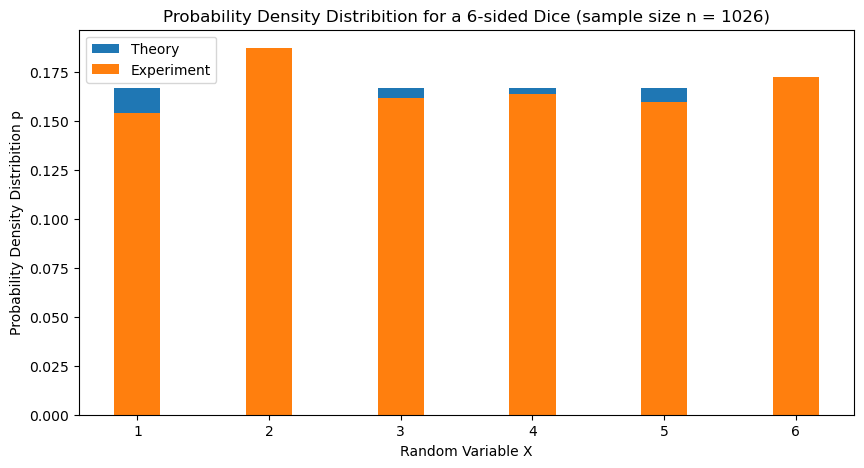

In [10]:
fig = plt.figure(figsize=(10., 5.))
pp = plt.bar(X, p, width, label='Theory')
pp = plt.bar(X, pdice, width, label='Experiment')
plt.ylabel('Probability Density Distribition p')
plt.xlabel('Random Variable X')
title = 'Probability Density Distribition for a 6-sided Dice (sample size n = ' + str(n) + ')'
plt.title(title)
plt.legend()
plt.show()

Consequently, there are also differences in the probability distribution ...

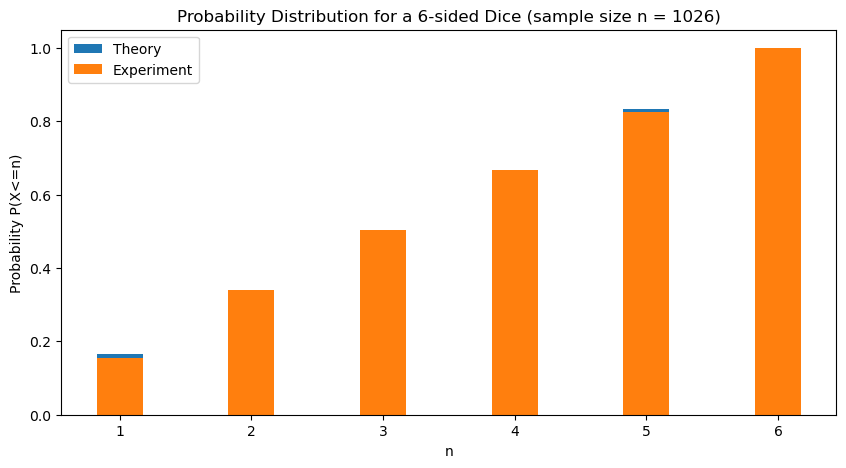

In [11]:
fig = plt.figure(figsize=(10., 5.))
# Estimate Probability Distribution P from Probability Density Distribution p
Pdice = np.cumsum(pdice)
Pp = plt.bar(X, P, width, label='Theory')
Pdicep = plt.bar(X, Pdice, width, label='Experiment')
plt.ylabel('Probability P(X<=n)')
plt.xlabel('n')
title = 'Probability Distribution for a 6-sided Dice (sample size n = ' + str(n) + ')'
plt.title(title)
plt.legend()
plt.show()

It is now also clear that the arithmetic mean $\bar{X}$ of the experiment ...

In [12]:
Xb = np.sum(X*pdice)
print('Xb = ',Xb)

Xb =  3.502923976608187


... deviates from the expected value $E$ of the theoretical probability model ...

In [13]:
E = np.sum(X*p)
print('E = ',E)

E =  3.5


**Law of large numbers**

The **law of large numbers** simply states that the arithmetic average of a large number of dice rolls converges towards the expected value.

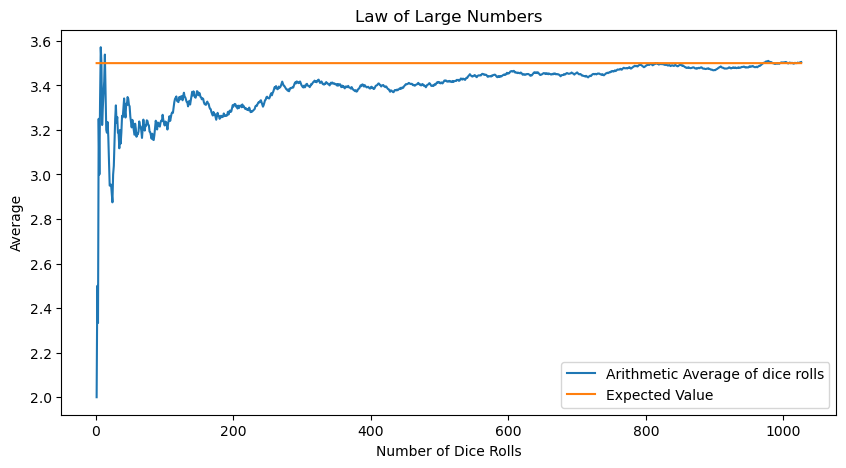

In [14]:
# Compute and plot cummulative mean of our dice dataset
N_LLN = np.arange(1,n+1,1)
cum_mean = np.cumsum(dice[0:n]) / N_LLN

# Compute expected value E
E = 3.5 * (N_LLN / N_LLN)

fig = plt.figure(figsize=(10., 5.))
plt.plot(N_LLN, cum_mean, label='Arithmetic Average of dice rolls')
plt.plot(N_LLN, E, label='Expected Value')
plt.ylabel('Average')
plt.xlabel('Number of Dice Rolls')
title = 'Law of Large Numbers'
plt.legend()
plt.title(title)
plt.show()

## Summary:

- A simple dice can be used to clearly illustrate fundamental stochastic concepts such as the probability space, a random variable, probability (density) distribution, and expected value.

- It is important to remember that the stochastic model of the dice is based on certain assumptions and therefore generally does not match the results of a random experiment using a real dice.

- More dice-related topics can be found here [Dice on Numberphile](https://www.youtube.com/playlist?list=PLt5AfwLFPxWKdwptEcseLGWnCKRjIx55T)